In [1]:
using CMPSExcitations

In [2]:
Hsingle(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     2 * c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁), (-Inf, +Inf));

In [3]:
c, μ = 10., 5.
tol = 1e-10
HLL = Hsingle(c, μ)

Ds = [8]
stateLL = find_groundstate(Ds, HLL, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
D = maximum(Ds)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])

Optimizing D=8


┌ Warning: The function `inner` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:196
┌ Warning: The function `scale` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Float64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:67
┌ Warning: The function `add!!` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}, Float64, VectorInterface.One}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:163
┌ Warning: The function `scalartype` is not implemented for (values of) type `Constant

D = 8 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 14.225267 seconds (47.69 M allocations: 2.524 GiB, 1.67% gc time, 67.19% compilation time: <1% of which was recompilation)
---------------
Energy density: 

┌ Info: YangGaudinCMPS ground state: converged after 504 iterations: e = -2.761265509087, ‖∇e‖ = 8.4974e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


-2.761265509087093
 Particle density: 0.4364772153805537
 Order parameter: 0.36173976585213763


In [5]:
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
HCLL = Hcoupled(c, μ)
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\nParticle density: ", expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[], "\nDensity imbalance: ", expval(ψ̂₁' * ψ̂₁ - ψ̂₂' * ψ̂₂, stateCLL)[])

Energy density: -2.76126550908698
Particle density: 0.8729544307611113
Density imbalance: 0.0


In [6]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E / sqrt(2) - M * Diagonal(F) / M
        W2 = E / sqrt(2) + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return P
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

excitation_matrix_constrained (generic function with 1 method)

In [9]:
_, M = eigen(stateLL.Rs[1][]);
P = projection_matrix(D, M)

Q = P[1:D^2, D^2+1:end]
Qn = Matrix(qr(Q).Q)
Pn = copy(P)
Pn[1:D^2, D^2+1:end] .= Qn / sqrt(2)
Pn[D^2+1:end, D^2+1:end] .= -Qn / sqrt(2);

In [16]:
space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
Heff = excitation_matrix(excitation_operator(HCLL, space), D);

In [17]:
round.(Pn' * Heff * Pn, digits=3)

72×72 Matrix{ComplexF64}:
  77.951+0.0im    -19.393+0.0im    …    4.219-0.0im     -2.138-0.0im
 -19.393+0.0im     85.228+0.0im         -4.99+0.0im      3.833+0.0im
 -20.957+0.0im     10.634+0.0im        -0.925-0.0im      2.749-0.0im
   0.671+0.0im     11.806+0.0im        -1.389+0.0im    -10.228+0.0im
   7.935+0.0im     11.774+0.0im         4.827-0.0im        1.3+0.0im
 -18.902+0.0im      5.348+0.0im    …     0.71-0.0im      0.398+0.0im
  -8.764+0.0im      4.342+0.0im         5.583-0.0im     -5.663+0.0im
  27.977+0.0im    -29.055+0.0im        -2.685+0.0im      1.964-0.0im
 -10.716+0.0im      1.794+0.0im        -5.191+0.0im      3.783+0.0im
  19.569+0.0im    -15.343+0.0im         2.538-0.0im     -7.432+0.0im
        ⋮                          ⋱         ⋮         
  -6.183+0.0im     19.189+0.0im          -3.7+0.0im      1.897-0.0im
   4.657-3.309im    -1.05+3.819im       2.866+4.998im    3.281-6.614im
  -7.076+1.241im   -0.981+2.195im  …  -10.253+6.428im   -1.394-2.575im
    -3.0+0.81im  

### Explicitly constructing goldstone modes

In [20]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E
        W2 = E + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q) # moves to an orthogonal projection
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

excitation_matrix_constrained (generic function with 1 method)

In [19]:
Hsingle_ll(c, μ) = ∫(∂ψ̂' * ∂ψ̂ - μ * ψ̂' * ψ̂ + c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
c, μ = 10., 5.
tol = 1e-10
Ds = [4, 8]
D = maximum(Ds)

HLL = Hsingle(c, μ)
stateLL = find_groundstate(Ds, HLL, InfiniteCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])

HCLL = Hcoupled(c, μ)
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateCLL)[], "\n Order parameter: ", expval(ψ̂, stateCLL)[])

Optimizing D=4


┌ Info: UniformCMPS ground state: initialization with e = 1176.846401464818
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 168 iterations: f = -5.050019379406, ‖∇f‖ = 1.5738e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 4 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
  2.951878 seconds (11.64 M allocations: 588.709 MiB, 2.02% gc time, 96.06% compilation time)
---------------
Optimizing D=8


┌ Info: UniformCMPS ground state: converged after 169 iterations: e = -5.050019379406, ‖∇e‖ = 1.5738e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127
┌ Info: UniformCMPS ground state: initialization with e = -5.050019379113
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 409 iterations: f = -5.101997460806, ‖∇f‖ = 7.5490e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 8 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
  3.594049 seconds (5.54 M allocations: 446.821 MiB, 1.50% gc time, 6.85% compilation time)
---------------
Energy density: -5.101997460806064
 Particle density: 0.7850064187771219
 Order parameter: -0.43098279532537453
Energy density: -2.655241675469504

┌ Info: UniformCMPS ground state: converged after 410 iterations: e = -5.101997460806, ‖∇e‖ = 7.5490e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127



 Particle density: 0.40133751372596543
 Order parameter: -0.3092564728805468


In [23]:
Q, R = stateCLL.Q[], stateCLL.Rs[1][];
W1, W2 = R, -R;

function leftgaugetv(Q, R, V, W1, W2, p)
    # assuming Q, R are in cMPS left gauge
    X, _ = linsolve(-R' * (W1 + W2) - V) do X
        (Q * X - X * Q) + 1im * p * X + 2 * R' * (R * X - X * R)
    end

    return V + (Q * X - X * Q) + 1im * p * X, W1 + (R * X - X * R), W2 + (R * X - X * R)
end

ps = range(0, 5., 20)
energies = zeros(ComplexF64, length(ps))
ρr = rightenv(stateCLL)[1][]

Threads.@threads for idx in eachindex(ps)
    V, W1, W2 = leftgaugetv(Q, R, zero(Q), R, -R, ps[idx])
    # ∫⟨H⟩ - ⟨H₀⟩ = E -> intensive contribution to energy on top of extensive ground state energy
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff, P = excitation_matrix_constrained(excitation_operator(HCLL, space), eigen(R).vectors)

    # Heff maps between D^2 + D subspace; so P * Heff * P' maps between 2D^2 space while keeping the multispecies constraint satisfied
    Ws = P * Heff * P' * vcat(vec(W1), vec(W2))

    HW1 = reshape(view(Ws, 1:D^2), D, D)
    HW2 = reshape(view(Ws, (D^2+1):2*D^2), D, D)

    energies[idx] = tr(HW1 * ρr * W1' + HW2 * ρr * W2')
end

energies

20-element Vector{ComplexF64}:
  44.18576111977051 - 1.3011675880700256e-13im
  44.27537083106957 + 0.08064622364154488im
 44.544199964966836 + 0.1612924472832184im
 44.992248521462216 + 0.2419386709248848im
  45.61951650055577 + 0.32258489456658906im
  46.42600390224752 + 0.4032311182082407im
  47.41171072653732 + 0.4838773418499316im
  48.57663697342537 + 0.5645235654916062im
  49.92078264291157 + 0.6451697891333011im
  51.44414773499594 + 0.7258160127749569im
  53.14673224967842 + 0.8064622364166383im
  55.02853618695908 + 0.8871084600583399im
 57.089559546837904 + 0.9677546836999846im
  59.32980232931487 + 1.048400907341687im
  61.74926453438997 + 1.1290471309833283im
  64.34794616206332 + 1.2096933546250161im
  67.12584721233476 + 1.290339578266707im
  70.08296768520441 + 1.370985801908382im
   73.2193075806721 + 1.4516320255500754im
  76.53486689873806 + 1.5322782491917484im

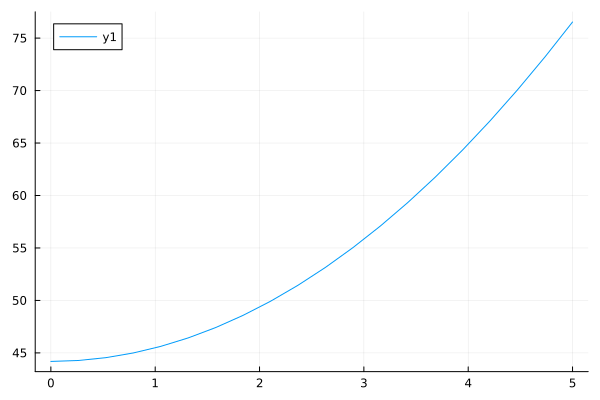

In [24]:
plot(ps, real.(energies))